<a href="https://colab.research.google.com/github/sasvi123/Neural_Network/blob/main/Task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Confusion Matrix ---
[[56  0]
 [ 0 52]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        56
           1       1.00      1.00      1.00        52

    accuracy                           1.00       108
   macro avg       1.00      1.00      1.00       108
weighted avg       1.00      1.00      1.00       108



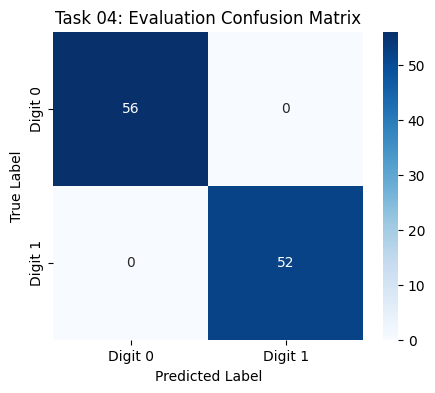

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import confusion_matrix, classification_report


# Step 1: Load and Preprocess the Dataset
digits = load_digits()

# Extract only digits 0 and 1
mask = (digits.target == 0) | (digits.target == 1)
X = digits.data[mask]
y = digits.target[mask]

# Feature scaling for uniform pixel gradients
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Train the Perceptron
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42)
model = Perceptron(max_iter=1000, eta0=0.1, random_state=42
                   )
model.fit(X_train, y_train)

# Step 3: Evaluate Performance
y_pred = model.predict(X_test)
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)

print(cm)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Step 4: Visualize Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Digit 0', 'Digit 1'],
            yticklabels=['Digit 0', 'Digit 1'])
plt.title("Task 04: Evaluation Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()